In [56]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from aquarel import load_theme
import scipy.stats as stats
from statsmodels.stats.multicomp import pairwise_tukeyhsd

FE_DF_PATH = Path("../data/processed/telco_customer_churn_feature_engineered.parquet")
fe_df = pd.read_parquet(FE_DF_PATH)

In [57]:
# look at the df
fe_df.head()

,Gender,SeniorCitizen,Partner,Dependents,Tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,...,MonthlyCharges,TotalCharges,NumServices,LongTimeCustomer,IsHighSpender,IsNewCustomer,TenureGroup,AutoPayment,HasSupportServices,Churn
0,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,...,29.850000,29.85,2,0,0,1,0-12,0,0,No
1,Male,0,No,No,34,Yes,No,DSL,Yes,No,...,56.950001,1889.50,4,0,0,0,24-48,0,1,No
2,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,...,53.849998,108.15,4,0,0,1,0-12,0,1,Yes
3,Male,0,No,No,45,No,No phone service,DSL,Yes,No,...,42.299999,1840.75,4,0,0,0,24-48,1,1,No
4,Female,0,No,No,2,Yes,No,Fiber optic,No,No,...,70.699997,151.65,2,0,0,1,0-12,0,0,Yes


In [58]:
# info
fe_df.isna().sum()

Gender                0
SeniorCitizen         0
Partner               0
Dependents            0
Tenure                0
PhoneService          0
MultipleLines         0
InternetService       0
OnlineSecurity        0
OnlineBackup          0
DeviceProtection      0
TechSupport           0
StreamingTV           0
StreamingMovies       0
Contract              0
PaperlessBilling      0
PaymentMethod         0
MonthlyCharges        0
TotalCharges          0
NumServices           0
LongTimeCustomer      0
IsHighSpender         0
IsNewCustomer         0
TenureGroup           0
AutoPayment           0
HasSupportServices    0
Churn                 0
dtype: int64

In [59]:
# duplicates
fe_df.duplicated().sum()

np.int64(22)

## Exploratory Data Analysis

In [60]:
# basic stats
fe_df.describe(include="number")

,SeniorCitizen,Tenure,MonthlyCharges,TotalCharges,NumServices,LongTimeCustomer,IsHighSpender,IsNewCustomer,AutoPayment,HasSupportServices
count,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000
mean,0.162147,32.371149,64.761696,2279.734304,4.146244,0.092432,0.100099,0.194661,0.435326,0.536561
std,0.368612,24.559481,30.090048,2266.794470,2.312720,0.289656,0.300154,0.395968,0.495835,0.498697
min,0.000000,0.000000,18.250000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,0.000000,9.000000,35.500000,398.550000,2.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,0.000000,29.000000,70.349998,1394.550000,4.000000,0.000000,0.000000,0.000000,0.000000,1.000000
75%,0.000000,55.000000,89.849998,3786.600000,6.000000,0.000000,0.000000,0.000000,1.000000,1.000000
max,1.000000,72.000000,118.750000,8684.800000,9.000000,1.000000,1.000000,1.000000,1.000000,1.000000


In [61]:
# set theme and matplotlib params
theme = load_theme("arctic_dark").set_grid(draw=True, alpha=0.1)
theme.apply()

plt.rcParams.update({
    "axes.titlesize": 18,
    "xtick.labelsize": 12,
    "ytick.labelsize": 12,
    "axes.labelsize": 14,
    "font.family": "monospace",
})

### Target Analysis

Is the target balanced?

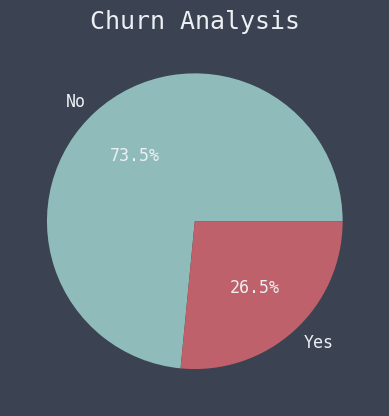

In [62]:
target_perc = fe_df.Churn.value_counts(normalize=True)
plt.pie(target_perc.values, autopct="%1.1f%%", labels=target_perc.index)
plt.title("Churn Analysis")
plt.show()

### Data Quality Assessment

In [63]:
duplicates = fe_df.duplicated().sum()
rows, cols = fe_df.shape

print(f"Duplicates as a % of rows: {((duplicates / rows) * 100):.2f}%")

Duplicates as a % of rows: 0.31%


### Numerical Feature Analysis

Are monthly charges normally distributed?

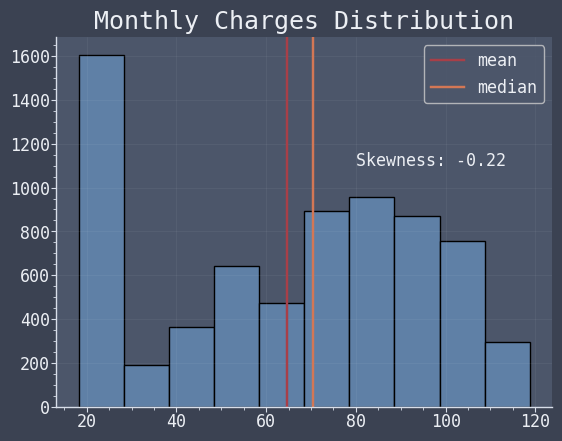

In [79]:
monthly_charges_stats = fe_df.MonthlyCharges.agg(["mean", "median", "skew"])

plt.hist(fe_df.MonthlyCharges, edgecolor="black", color="#5f80a6")
plt.title("Monthly Charges Distribution")
plt.axvline(monthly_charges_stats.iloc[0], label="mean", color="#a83f48")
plt.axvline(monthly_charges_stats.iloc[1], label="median", color="#d37755")
plt.text(x=80, y=1100, s=f"Skewness: {monthly_charges_stats.iloc[2]:.2f}")
plt.legend()
plt.show()

How many people are long-time customers?

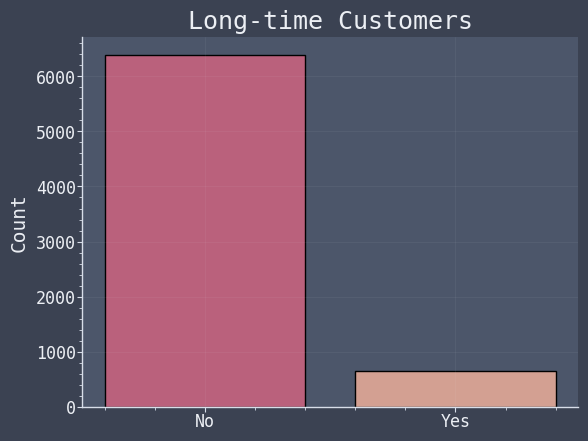

In [65]:
long_time_cust = fe_df.LongTimeCustomer.value_counts()

plt.bar(long_time_cust.index, long_time_cust.values, edgecolor="black", color=["#ba617c", "#d3a092"])
plt.title("Long-time Customers")
plt.xticks([0, 1], ["No", "Yes"])
plt.ylabel("Count")
plt.show()

### Categorical Feature Analysis

Does gender affect tenure? Do male churn less than females?

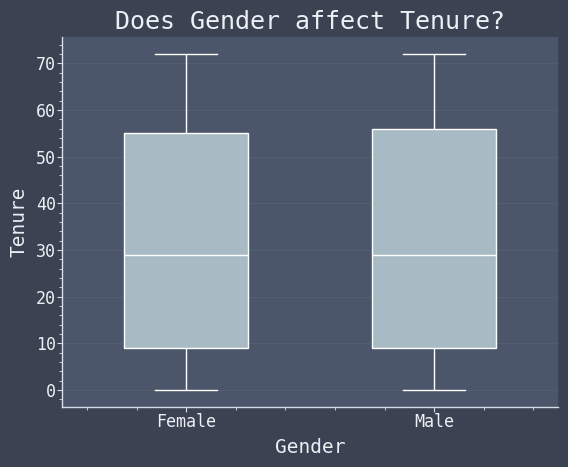

In [66]:
sns.boxplot(data=fe_df, x="Gender", y="Tenure", width=0.5, color="#a3bdc9", linecolor="#fff")
plt.title("Does Gender affect Tenure?")
plt.show()

Does having a partner increase spending?

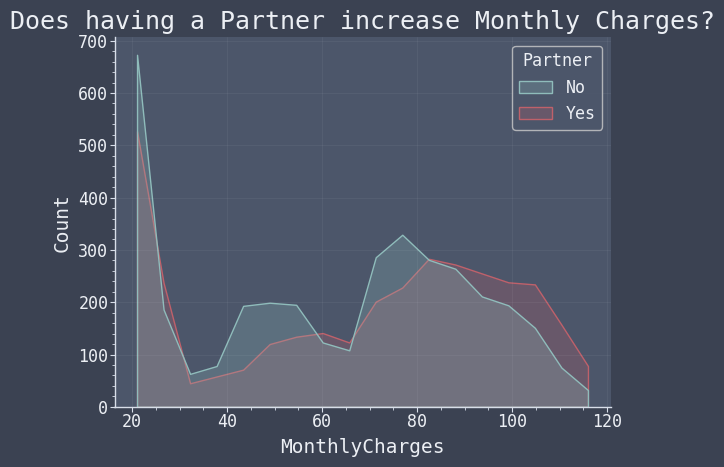

In [67]:
sns.histplot(data=fe_df, x="MonthlyCharges", hue="Partner", element="poly")
plt.title("Does having a Partner increase Monthly Charges?")
plt.show()

What's the average total spending per tenure group?

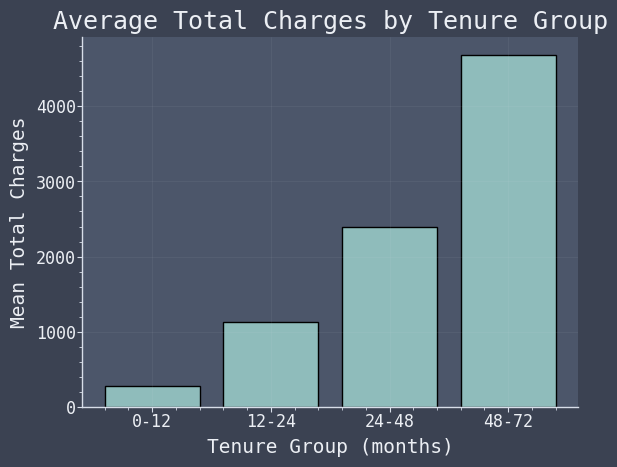

In [68]:
avg_spending_tenure_group = fe_df.groupby("TenureGroup").TotalCharges.mean()

plt.bar(avg_spending_tenure_group.index, avg_spending_tenure_group.values.flatten(), edgecolor="black")
plt.title("Average Total Charges by Tenure Group")
plt.xlabel("Tenure Group (months)")
plt.ylabel("Mean Total Charges")
plt.show()

### Feature vs. Target Analysis

Do customers who churn pay more?

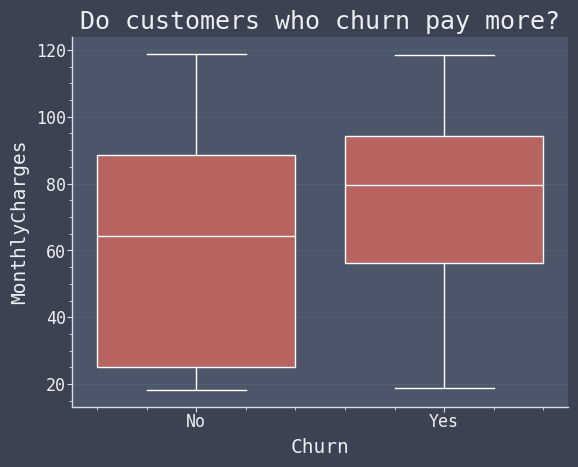

In [69]:
sns.boxplot(data=fe_df, x="Churn", y="MonthlyCharges", color="#c65550", linecolor="#fff")
plt.title("Do customers who churn pay more?")
plt.show()

How many senior citizens churn?

In [70]:
pd.crosstab(index=fe_df.SeniorCitizen, columns=fe_df.Churn, normalize="index")

Churn,No,Yes
SeniorCitizen,,
0,0.763938,0.236062
1,0.583187,0.416813


Does having multiple lines increase churn?

In [71]:
pd.crosstab(index=fe_df.MultipleLines, columns=fe_df.Churn, normalize="index")

Churn,No,Yes
MultipleLines,,
No,0.749558,0.250442
No phone service,0.750733,0.249267
Yes,0.713901,0.286099


Do customers that have support services churn less?

In [72]:
pd.crosstab(index=fe_df.HasSupportServices, columns=fe_df.Churn, normalize="index")

Churn,No,Yes
HasSupportServices,,
0,0.685355,0.314645
1,0.777190,0.222810


Does contract affect churn?

In [73]:
pd.crosstab(fe_df.Contract, fe_df.Churn, normalize="index")

Churn,No,Yes
Contract,,
Month-to-month,0.572903,0.427097
One year,0.887305,0.112695
Two year,0.971681,0.028319


What about tenure group?

In [74]:
pd.crosstab(fe_df.TenureGroup, fe_df.Churn, normalize="index")

Churn,No,Yes
TenureGroup,,
0-12,0.525618,0.474382
12-24,0.712891,0.287109
24-48,0.796110,0.203890
48-72,0.904868,0.095132


### Correlation Analysis

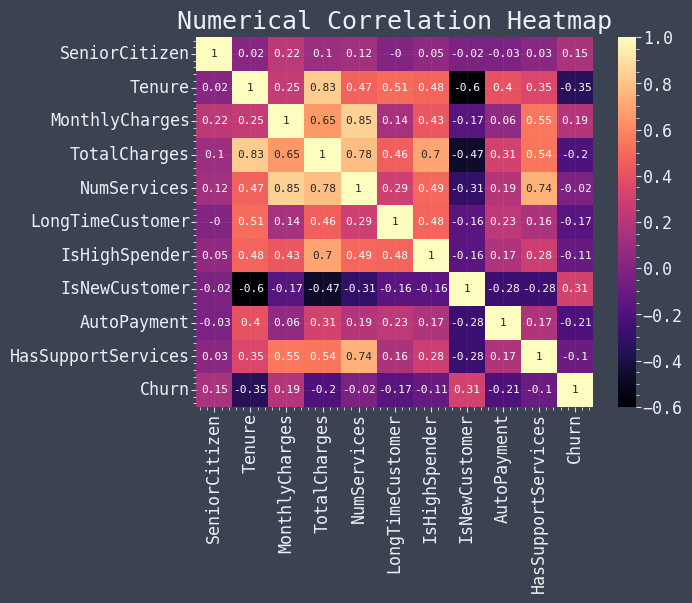

In [75]:
fe_df_copy = fe_df.copy()
fe_df_copy.Churn = fe_df_copy.Churn.map({"Yes": 1, "No": 0})
num_corrs = fe_df_copy.corr(numeric_only=True).round(2)

sns.heatmap(num_corrs, annot=True, cmap="magma", annot_kws={"fontsize": 8})
plt.title("Numerical Correlation Heatmap")
plt.show()

### ANOVA Analysis

Does mean monthly charges differ across payment methods?

In [76]:
f_stat, p_value = stats.f_oneway(
    fe_df[fe_df.PaymentMethod == "Electronic check"].MonthlyCharges,
    fe_df[fe_df.PaymentMethod == "Mailed check"].MonthlyCharges,
    fe_df[fe_df.PaymentMethod == "Bank transfer (automatic)"].MonthlyCharges,
    fe_df[fe_df.PaymentMethod == "Credit card (automatic)"].MonthlyCharges,
)

print(f"F-stat: {f_stat:.2f} | p-value: {p_value}")

F-stat: 450.32 | p-value: 0.0


But which payment methods differ?

In [77]:
tukey_hsd = pairwise_tukeyhsd(fe_df.MonthlyCharges, fe_df.PaymentMethod, alpha=0.05)
tukey_hsd_df = pd.DataFrame(data=tukey_hsd._results_table.data[1:], columns=tukey_hsd._results_table.data[0])
# look at the results
tukey_hsd_df

,group1,group2,meandiff,p-adj,lower,upper,reject
0,Bank transfer (automatic),Credit card (automatic),-0.6803,0.9035,-3.2390,1.8784,False
1,Bank transfer (automatic),Electronic check,9.0632,0.0000,6.7455,11.3809,True
2,Bank transfer (automatic),Mailed check,-23.2756,0.0000,-25.7981,-20.7531,True
3,Credit card (automatic),Electronic check,9.7434,0.0000,7.4156,12.0712,True
4,Credit card (automatic),Mailed check,-22.5953,0.0000,-25.1271,-20.0636,True
5,Electronic check,Mailed check,-32.3388,0.0000,-34.6267,-30.0508,True


## Exploratory Data Analysis Conclusions

1.	Target Analysis: according to the data, 73.5% of people didn’t churn, with the remaining ones staying. This suggests class imbalance, which will have to be tackled in machine learning through balanced class weights.
2.	Numerical Feature Analysis:
-	Monthly charges exhibit a slight negative skew (skewness = -0.22). The distribution also appears bimodal, with one cluster of customers paying around $20–30 per month and another cluster paying roughly $70–110 per month, suggesting the presence of distinct customer segments.
-	Most of the dataset is comprised of people that aren’t long-time customers.
3.	Categorical Feature Analysis:
-	According to the data, gender doesn’t influence tenure meaningfully. The tenure distribution is roughly the same for both men and women. 
-	Having a partner doesn’t increase monthly charges compared to not having one, according to the data. The monthly distribution of charges for both categories is close to the other.
4.	Feature vs. Target Analysis:
-	Customers who churn have higher monthly charges compared to those that don’t. This suggests that pricing matters when it comes to retaining people.
-	According to the data, 76% of people who are not senior citizens don’t churn compared to 58% for those who are. 
-	People that have support services such as online security, tech support and device protection churn less (22%) vs. those that don’t (31%).
-	According to the data, contract does affect churn: only 3% people on a two-year contract churn, with the value increasing for those on a yearly contract (11%) and those on a month-to-month contract (43%). Contract type appears to be one of the strongest indicators of churn in the dataset.
-	Tenure also affects churning, with only 9.5% of people in higher groups (48-72 months) churning. The percentage increases for lower groups: 20% for those in the 24-48 group, 29% for those in the 12-24 group and 47% for those in the 0-12 group.
5.	Correlation Analysis:
-	Most numerical features exhibit only weak linear correlations with churn. However, weak correlation does not necessarily imply low predictive value, particularly for tree-based models capable of capturing nonlinear relationships.
6.	ANOVA:
-	I use ANOVA to compare whether monthly charges differ across payment methods. The high f-stat of 450.32 suggests that groups differ a lot and the <0.05 p-value signifies that differences are statistically significant.
-	Tukey HSD is used to understand which groups differ. Only one group’s mean isn’t different from the other one, namely bank transfer vs. credit card. The mean difference is low, -0.7, meaning that credit card’s mean is, on average, $0.7 lower compared to bank transfer’s. 
All the other group comparisons have statistically significant differences, therefore the null hypothesis for all is rejected.